In [1]:
from ultralytics import YOLO

In [2]:
model = YOLO("yolo11n-seg.pt")  # load a pretrained model (recommended for training)

In [3]:
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95(B)
metrics.box.map50  # map50(B)
metrics.box.map75  # map75(B)
metrics.box.maps  # a list contains map50-95(B) of each category
metrics.seg.map  # map50-95(M)
metrics.seg.map50  # map50(M)
metrics.seg.map75  # map75(M)
metrics.seg.maps  # a list contains map50-95(M) of each category


Ultralytics 8.3.204 🚀 Python-3.9.23 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 15978MiB)
YOLO11n-seg summary (fused): 113 layers, 2,868,664 parameters, 0 gradients, 9.7 GFLOPs


FileNotFoundError: '/ultralytics/ultralytics/cfg/datasets/coco.yaml' does not exist

In [4]:
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/kaarl/Developer/ai-learning-journey/cv-course/16-ultralytics/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 140.7ms
Speed: 28.3ms preprocess, 140.7ms inference, 714.3ms postprocess per image at shape (1, 3, 640, 480)


In [ ]:
# Install required packages for visualization
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import requests
from io import BytesIO

\nDetected 6 objects:
  1. bus: 0.898 confidence
     Bounding box: (19.7, 230.0, 801.8, 744.1)
  2. person: 0.885 confidence
     Bounding box: (670.1, 390.6, 809.6, 875.3)
  3. person: 0.863 confidence
     Bounding box: (49.5, 398.1, 240.8, 905.1)
  4. person: 0.822 confidence
     Bounding box: (222.7, 404.5, 346.1, 859.9)
  5. stop sign: 0.461 confidence
     Bounding box: (0.1, 254.6, 32.0, 325.7)
  6. person: 0.442 confidence
     Bounding box: (0.0, 555.4, 74.8, 875.0)


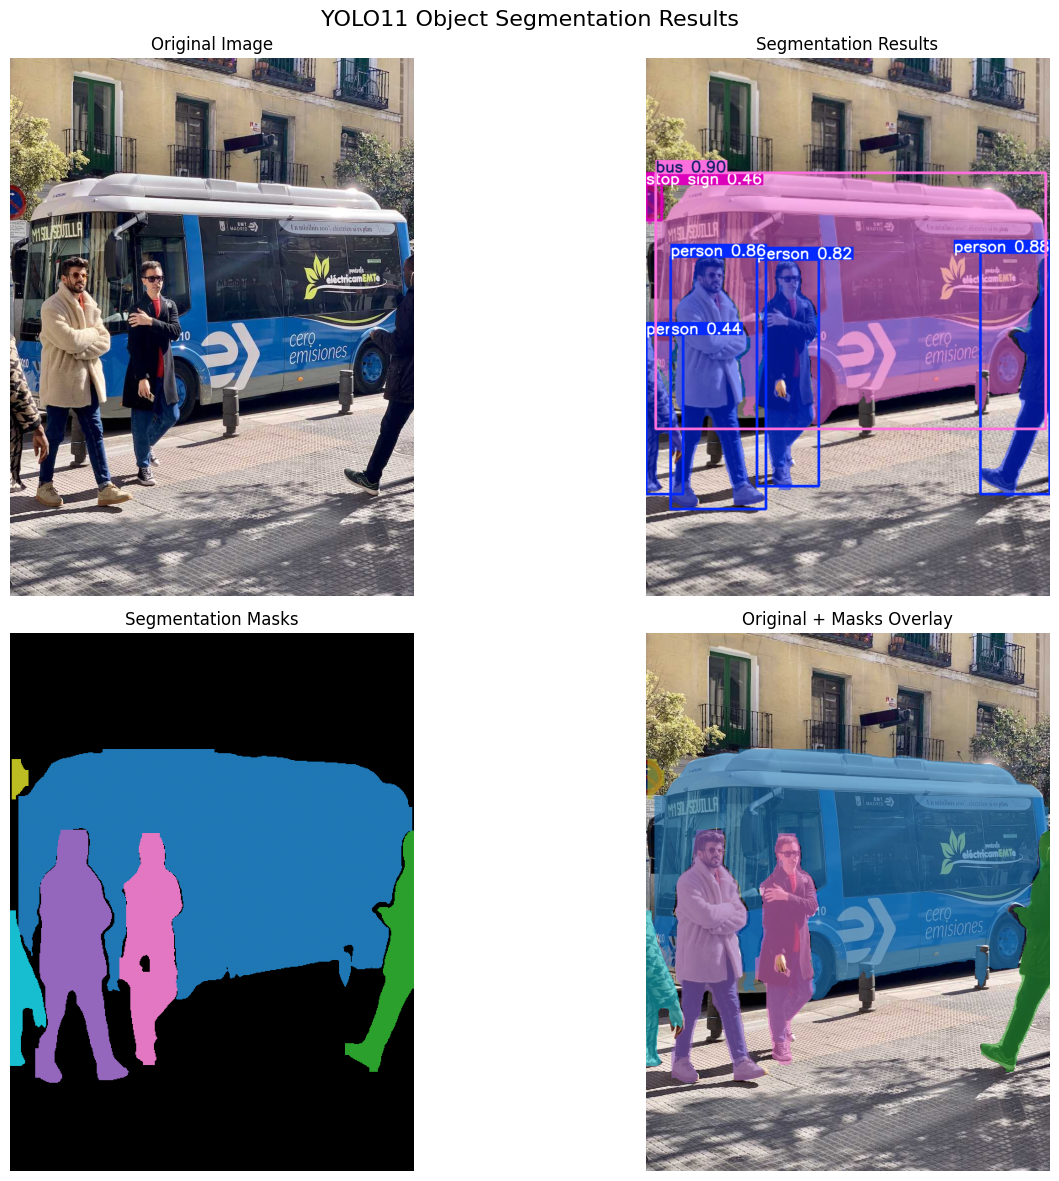

In [7]:
# Load and display the original image
image_url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(image_url)
original_image = Image.open(BytesIO(response.content))
original_array = np.array(original_image)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('YOLO11 Object Segmentation Results', fontsize=16)

# Display original image
axes[0, 0].imshow(original_image)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Process results and create visualizations
for result in results:
    # Get the annotated image from YOLO (with boxes and masks)
    annotated_img = result.plot()
    
    # Display annotated image
    axes[0, 1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Segmentation Results')
    axes[0, 1].axis('off')
    
    if result.masks is not None:
        # Extract mask data
        masks = result.masks.data.cpu().numpy()  # (num_objects, H, W)
        boxes = result.boxes.xyxy.cpu().numpy()  # bounding boxes
        classes = result.boxes.cls.cpu().numpy()  # class indices
        confidences = result.boxes.conf.cpu().numpy()  # confidence scores
        
        # Create combined mask visualization
        combined_mask = np.zeros_like(masks[0])
        colors = plt.cm.tab10(np.linspace(0, 1, len(masks)))
        
        # Overlay all masks with different colors
        mask_overlay = np.zeros((*masks[0].shape, 3))
        for i, (mask, color) in enumerate(zip(masks, colors)):
            mask_overlay[mask > 0.5] = color[:3]
            combined_mask = np.maximum(combined_mask, mask * (i + 1))
        
        # Display individual masks
        axes[1, 0].imshow(mask_overlay)
        axes[1, 0].set_title('Segmentation Masks')
        axes[1, 0].axis('off')
        
        # Create overlay of original image with masks
        overlay = original_array.copy().astype(float) / 255.0
        alpha = 0.6
        for i, (mask, color) in enumerate(zip(masks, colors)):
            mask_resized = cv2.resize(mask, (original_array.shape[1], original_array.shape[0]))
            for c in range(3):
                overlay[:, :, c] = np.where(mask_resized > 0.5, 
                                          overlay[:, :, c] * (1 - alpha) + color[c] * alpha,
                                          overlay[:, :, c])
        
        axes[1, 1].imshow(overlay)
        axes[1, 1].set_title('Original + Masks Overlay')
        axes[1, 1].axis('off')
        
        # Print detection information
        print(f"\\nDetected {len(masks)} objects:")
        for i, (cls, conf, box) in enumerate(zip(classes, confidences, boxes)):
            class_name = result.names[int(cls)]
            print(f"  {i+1}. {class_name}: {conf:.3f} confidence")
            print(f"     Bounding box: ({box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f})")
    
    else:
        print("No masks detected in the image")

plt.tight_layout()
plt.show()


In [8]:
# Alternative: Simple visualization using YOLO's built-in methods
# This is the easiest way to visualize results

# Method 1: Save annotated image
for i, result in enumerate(results):
    result.save(f"segmentation_result_{i}.jpg")  # Save annotated image
    print(f"Saved segmentation_result_{i}.jpg")

# Method 2: Show results directly (if in interactive environment)
# results[0].show()  # Uncomment this line to show in a window

# Method 3: Access individual mask polygons for custom visualization
print("\\nMask polygon coordinates:")
for result in results:
    if result.masks is not None:
        xy = result.masks.xy  # mask in polygon format
        xyn = result.masks.xyn  # normalized coordinates
        
        for i, (polygon, norm_polygon) in enumerate(zip(xy, xyn)):
            print(f"Object {i+1}:")
            print(f"  Polygon points: {len(polygon)} points")
            print(f"  First 3 points (pixel coords): {polygon[:3].tolist()}")
            print(f"  First 3 points (normalized): {norm_polygon[:3].tolist()}")
            print()


Saved segmentation_result_0.jpg
\nMask polygon coordinates:
Object 1:
  Polygon points: 670 points
  First 3 points (pixel coords): [[185.625, 232.875], [185.625, 237.9375], [183.9375, 239.625]]
  First 3 points (normalized): [[0.2291666716337204, 0.21562500298023224], [0.2291666716337204, 0.22031250596046448], [0.22708334028720856, 0.22187499701976776]]

Object 2:
  Polygon points: 233 points
  First 3 points (pixel coords): [[804.9375, 396.5625], [803.25, 398.25], [801.5625, 398.25]]
  First 3 points (normalized): [[0.9937499761581421, 0.3671875], [0.9916666746139526, 0.3687500059604645], [0.9895833134651184, 0.3687500059604645]]

Object 3:
  Polygon points: 319 points
  First 3 points (pixel coords): [[101.25, 394.875], [101.25, 401.625], [99.5625, 403.3125]]
  First 3 points (normalized): [[0.125, 0.3656249940395355], [0.125, 0.37187498807907104], [0.12291666865348816, 0.3734374940395355]]

Object 4:
  Polygon points: 210 points
  First 3 points (pixel coords): [[264.9375, 401.625]